# Тестовый ноутбук оптимизатора площади дерева с валентностью

Этот ноутбук предназначен для пошагового тестирования нового оптимизатора:
- `src/logic/tree/area_opt/optimize_tree_area_with_valence.py`
- `src/managers/valence_manager.py`

**Данные:** `scripts/run/buffer/real_graph_latest.json`

---

## Шаг 1: Загрузка и визуализация графа

В этом шаге мы:
1. Загрузим граф из JSON
2. Визуализируем спoры в фазовом пространстве (θ, ω)
3. Покажем связи между спорами с цветовым кодированием
4. Выведем таблицу со всеми спорами

In [1]:
# Импорт необходимых модулей
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import to_rgb

# Настройка matplotlib для лучшего отображения
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("✅ Модули загружены")

✅ Модули загружены


In [2]:
# Загрузка графа из JSON
json_path = Path(r"C:\GitHub\diplom\spores\v16_picker\scripts\run\buffer\real_graph_latest.json")

if not json_path.exists():
    raise FileNotFoundError(f"Файл не найден: {json_path}")

with open(json_path, 'r', encoding='utf-8') as f:
    graph_data = json.load(f)

print("✅ Граф загружен из JSON")
print(f"\n📊 Статистика:")
print(f"   Всего спор: {graph_data['statistics']['total_spores']}")
print(f"   Всего связей: {graph_data['statistics']['total_links']}")
print(f"   Goal спор: {graph_data['statistics']['goal_spores']}")
print(f"\n⏰ Экспортировано: {graph_data['metadata']['export_time']}")

✅ Граф загружен из JSON

📊 Статистика:
   Всего спор: 10
   Всего связей: 12
   Goal спор: 1

⏰ Экспортировано: 2025-10-17T05:43:56.668235


In [3]:
# Функция для визуализации графа спор
def visualize_spore_graph(graph_data, figsize=(16, 12), show_legend=True):
    """
    Визуализирует граф спор в фазовом пространстве (θ, ω).
    
    Показывает:
    - Спoры с номерами (#1, #2, ...)
    - Позиции в (θ, ω)
    - Связи со стрелками
    - Цветовое кодирование: goal (зеленый) vs обычные (синий)
    - Управление: max (красный) vs min (голубой)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    spores = graph_data['spores']
    links = graph_data['links']
    
    # Цветовые схемы
    color_goal = '#2ECC71'  # Зеленый для goal
    color_normal = '#3498DB'  # Синий для обычных
    color_max_control = '#FF6B6B'  # Красный для u_max
    color_min_control = '#1ABC9C'  # Бирюзовый для u_min
    
    # Словарь для быстрого поиска позиций по spore_id
    spore_positions = {}
    
    # Рисуем связи (стрелки) - сначала, чтобы они были под точками
    for link in links:
        parent_id = str(link['parent_spore_id'])
        child_id = str(link['child_spore_id'])
        control = link['control']
        
        # Находим позиции спор
        parent_spore = next((s for s in spores if str(s['spore_id']) == parent_id), None)
        child_spore = next((s for s in spores if str(s['spore_id']) == child_id), None)
        
        if parent_spore and child_spore:
            pos_parent = parent_spore['position']
            pos_child = child_spore['position']
            
            # Цвет стрелки по типу управления
            arrow_color = color_max_control if control > 0 else color_min_control
            
            # Рисуем стрелку
            arrow = FancyArrowPatch(
                (pos_parent[0], pos_parent[1]),
                (pos_child[0], pos_child[1]),
                arrowstyle='-|>',
                mutation_scale=20,
                linewidth=2,
                color=arrow_color,
                alpha=0.6,
                zorder=1
            )
            ax.add_patch(arrow)
    
    # Рисуем споры
    for spore in spores:
        pos = spore['position']
        spore_id = str(spore['spore_id'])
        index = spore['index']
        is_goal = spore['is_goal']
        
        spore_positions[spore_id] = pos
        
        # Цвет и размер споры
        color = color_goal if is_goal else color_normal
        size = 500 if is_goal else 300
        
        # Рисуем спору
        ax.scatter(pos[0], pos[1], s=size, c=color, alpha=0.8, 
                  edgecolors='black', linewidths=2, zorder=3)
        
        # Номер споры (как на картинке: #1, #2, ...)
        label = f"#{index + 1}"
        ax.text(pos[0], pos[1], label, 
               fontsize=12, fontweight='bold',
               ha='center', va='center',
               color='white', zorder=4)
        
        # ID споры рядом с точкой
        ax.text(pos[0], pos[1] - 0.015, f"ID:{spore_id}",
               fontsize=8, ha='center', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
               zorder=4)
    
    # Настройка осей
    ax.set_xlabel('θ (угол, rad)', fontsize=14, fontweight='bold')
    ax.set_ylabel('θ̇ (угловая скорость, rad/s)', fontsize=14, fontweight='bold')
    ax.set_title(
        f'Граф спор в фазовом пространстве\n'
        f'Спор: {len(spores)}, Связей: {len(links)}',
        fontsize=16, fontweight='bold', pad=20
    )
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Легенда
    if show_legend:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color_goal, 
                  markersize=12, label='Goal спора', markeredgecolor='black', markeredgewidth=2),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color_normal, 
                  markersize=10, label='Обычная спора', markeredgecolor='black', markeredgewidth=2),
            Line2D([0], [0], color=color_max_control, linewidth=3, 
                  label='Управление u_max (+)', alpha=0.7),
            Line2D([0], [0], color=color_min_control, linewidth=3, 
                  label='Управление u_min (-)', alpha=0.7),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)
    
    plt.tight_layout()
    return fig, ax

print("✅ Функция визуализации готова")

✅ Функция визуализации готова


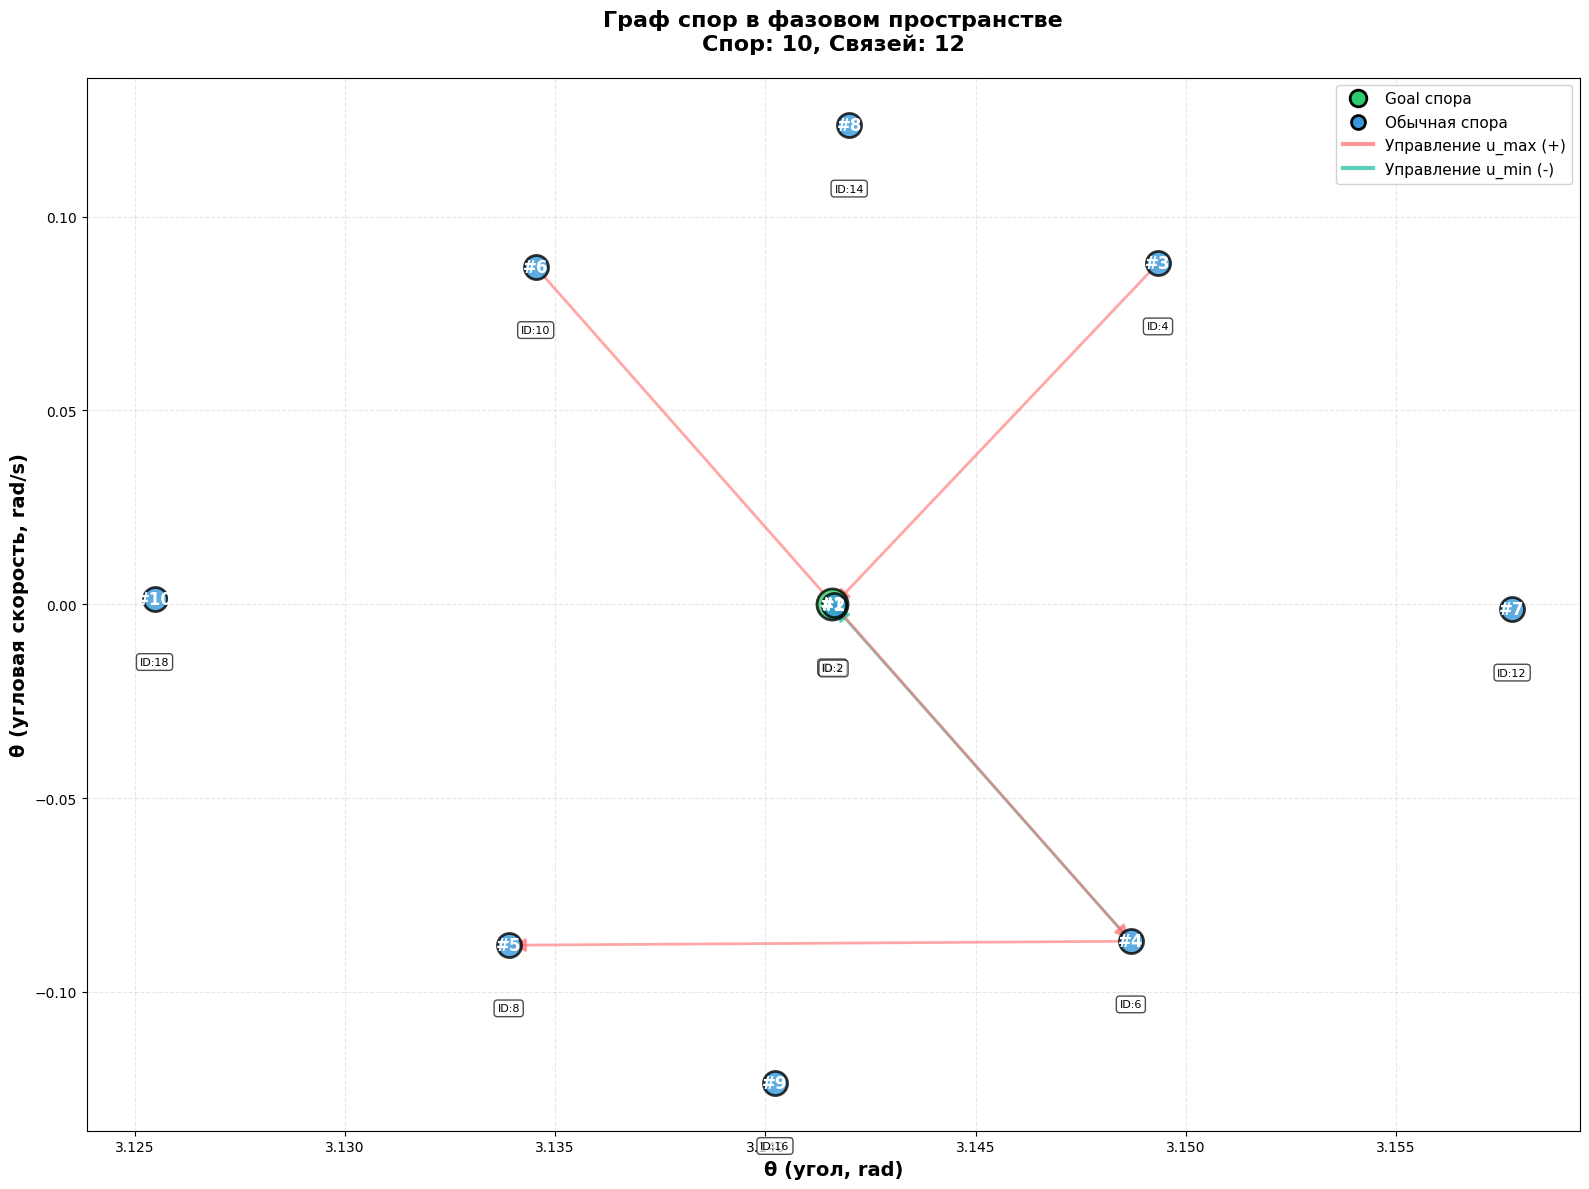


✅ Граф визуализирован


In [4]:
# Визуализация графа
fig, ax = visualize_spore_graph(graph_data, figsize=(16, 12), show_legend=True)
plt.show()

print("\n✅ Граф визуализирован")

In [5]:
# Создание таблицы со всеми спорами
spore_table_data = []

for spore in graph_data['spores']:
    spore_id = spore['spore_id']
    index = spore['index']
    position = spore['position']
    is_goal = spore['is_goal']
    cost = spore['cost']
    
    # Подсчет связей
    in_links_count = len(spore['in_links'])
    out_links_count = len(spore['out_links'])
    total_links = in_links_count + out_links_count
    
    spore_table_data.append({
        'Индекс': f"#{index + 1}",
        'ID': spore_id,
        'θ (rad)': f"{position[0]:.6f}",
        'θ̇ (rad/s)': f"{position[1]:.6f}",
        'Goal': '✅' if is_goal else '❌',
        'Cost': f"{cost:.6f}",
        'Входящие': in_links_count,
        'Исходящие': out_links_count,
        'Всего связей': total_links
    })

# Создаем DataFrame для красивого отображения
df_spores = pd.DataFrame(spore_table_data)

print("\n📋 ТАБЛИЦА ВСЕХ СПОР:")
print("="*100)
display(df_spores)
print("="*100)

# Статистика по связям
print(f"\n📊 Статистика связей:")
print(f"   Средняя степень узла: {df_spores['Всего связей'].mean():.2f}")
print(f"   Макс. связей у споры: {df_spores['Всего связей'].max()}")
print(f"   Мин. связей у споры: {df_spores['Всего связей'].min()}")
print(f"   Всего входящих связей: {df_spores['Входящие'].sum()}")
print(f"   Всего исходящих связей: {df_spores['Исходящие'].sum()}")


📋 ТАБЛИЦА ВСЕХ СПОР:


,Индекс,ID,θ (rad),θ̇ (rad/s),Goal,Cost,Входящие,Исходящие,Всего связей
0,#1,1,3.141590,0.000000,✅,0.000000,0,0,0
1,#2,2,3.141619,-0.000287,❌,0.000289,2,2,4
2,#3,4,3.149336,0.087953,❌,0.088293,2,1,3
3,#4,6,3.148690,-0.086957,❌,0.087247,1,2,3
4,#5,8,3.133894,-0.087978,❌,0.088314,2,1,3
5,#6,10,3.134536,0.087011,❌,0.087297,1,2,3
6,#7,12,3.157758,-0.001355,❌,0.016225,1,1,2
7,#8,14,3.141992,0.123514,❌,0.123514,1,1,2
8,#9,16,3.140227,-0.123486,❌,0.123494,1,1,2
9,#10,18,3.125472,0.001373,❌,0.016177,1,1,2



📊 Статистика связей:
   Средняя степень узла: 2.40
   Макс. связей у споры: 4
   Мин. связей у споры: 0
   Всего входящих связей: 12
   Всего исходящих связей: 12


---

## Результаты Шага 1

### Что мы получили:
1. ✅ Граф загружен из JSON: 10 спор, 12 связей
2. ✅ Визуализация показывает:
   - Номера спор (#1, #2, ...)
   - Позиции в фазовом пространстве (θ, ω)
   - Связи с цветовым кодированием:
     - Красные стрелки: u_max (максимальное управление)
     - Бирюзовые стрелки: u_min (минимальное управление)
   - Goal спора (зеленая) vs обычные (синие)
3. ✅ Таблица со всеми спорами и их связями

### Следующий шаг:
После подтверждения пользователя переходим к **Шагу 2: Анализ валентности для каждой споры**

---